Check **Setup**

In [3]:
# platform - built-in python library
# gives info about the system we are running on
import platform
import subprocess
import os

In [4]:
print("Python version", platform.python_version())

Python version 3.12.13


In [5]:
import torch

if torch.cuda.is_available():
  print("GPU available")
else:
  print("No GPU - using CPU")

GPU available


Mount **Google Drive**

In [6]:
# drive lets us connect our Google Drive to this collab
from google.colab import drive
import os

# os helps to interact with the file system


drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/neurosynth"

os.makedirs(PROJECT_DIR, exist_ok=True)

# create a raw data folder - download EEG files go here
os.makedirs(f"{PROJECT_DIR}/data/raw", exist_ok=True)

# create the processed data folder - cleaned numpy arrays go here
os.makedirs(f"{PROJECT_DIR}/data/processed", exist_ok=True)

Mounted at /content/drive


Installing packages

In [7]:
# mne is a EEG processing library
# mlflow tracks our training experiments (loss, accuracy, parameters)

!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 87.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [8]:
import mne  # EEG processing
import numpy as np

Download EEG Data

In [9]:
from mne.datasets import eegbci

# where to save the raw downloaded files (on Google Drive)
DATA_DIR = "/content/drive/MyDrive/neurosynth/data/raw"


# People whose brain signals were recoreded (starts with 5)
SUBJECTS = [1, 2, 3, 4, 5]

# Recording sessions (6, 10, 14 are the motor IMAGERY sessions)
RUNS = [6, 10, 14]

print("Downloading EEG Data.... \n")

for subject in SUBJECTS:
  raw_fnames = eegbci.load_data(
      subject,  # which person
      runs = RUNS, # which session
      path = DATA_DIR,   # where to save the data
      verbose = False  # don't print MNE's internal logs

  )

  # raw_fnames is the list of file paths that were downloaded
  print(f"Subject {subject:03d} - {len(raw_fnames)} files downloaded")


Do you want to set the path:
    /content/drive/MyDrive/neurosynth/data/raw
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Subject 001 - 3 files downloaded
Subject 002 - 3 files downloaded
Subject 003 - 3 files downloaded
Subject 004 - 3 files downloaded
Subject 005 - 3 files downloaded


In [10]:
# look inside one EEG file
# concatenate_raws joins multiple recordings into one
from mne.io import concatenate_raws

# load just subject 1, run 6
raw_fnames = eegbci.load_data(
    1,  # subject number
    runs = [6],
    path = DATA_DIR,
    verbose = False
)


# read_raw_edf reads the .edf file (European Data Format)
# .edf is the standard file format for biological signal recordings
raw = mne.io.read_raw_edf(raw_fnames[0], preload = True, verbose = False)


# ch_names is a list of all electrode names
print(f"Channels: {len(raw.ch_names)}")

# sfreq = sampling frequency = how many readings per second
print(f"Sampe rate:  {raw.info["sfreq"]} Hz")

# raw.times is an array of every
print(f"Duration: {raw.times[-1]:.1f} seconds")

# get_data() returns the raw signal as a numpy array
print(f"Data shape: {raw.get_data().shape}")
print(f"            (channels, timepoints)")


print(f"\nFirst 5 channels: {raw.ch_names[:5]}")


# annotations are the labels - timestamps marking when each task happened
# T0 = rest, T1 = left first imagery, T2, = right first imegery
print(f"\nAnnotations")
for ann in raw.annotations:
  print(f"  {ann['onset']:.1f}s "
        f"duration={ann['duration']:.1f}s   " # how long it lasted
        f" label ={ann['description']}' ")  # what task it was



Channels: 64
Sampe rate:  160.0 Hz
Duration: 125.0 seconds
Data shape: (64, 20000)
            (channels, timepoints)

First 5 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.']

Annotations
  0.0s duration=4.2s    label =T0' 
  4.2s duration=4.1s    label =T2' 
  8.3s duration=4.2s    label =T0' 
  12.5s duration=4.1s    label =T1' 
  16.6s duration=4.2s    label =T0' 
  20.8s duration=4.1s    label =T1' 
  24.9s duration=4.2s    label =T0' 
  29.1s duration=4.1s    label =T2' 
  33.2s duration=4.2s    label =T0' 
  37.4s duration=4.1s    label =T1' 
  41.5s duration=4.2s    label =T0' 
  45.7s duration=4.1s    label =T2' 
  49.8s duration=4.2s    label =T0' 
  54.0s duration=4.1s    label =T2' 
  58.1s duration=4.2s    label =T0' 
  62.3s duration=4.1s    label =T1' 
  66.4s duration=4.2s    label =T0' 
  70.6s duration=4.1s    label =T1' 
  74.7s duration=4.2s    label =T0' 
  78.9s duration=4.1s    label =T2' 
  83.0s duration=4.2s    label =T0' 
  87.2s duration=4.1s    label =T2'

In [31]:
# Check for dead/bad channels

# A 'dead' channel has zero or near-zero variance
# This means the electrode wasn't making good contact with the scalp
# and reorded essentially nothing useful

data = raw.get_data()

print(data.shape)


# compare each channe's std to the AVERAGE std across all channels
# A channel is suspicious if its std is much smaller than its peers
channel_std = data.std(axis = 1)


median_std = np.median(channel_std)
threshold = median_std * 0.05 # 5% of typical channel variation

print("Channel Quality Check")
for i, (ch_name, std) in enumerate(zip(raw.ch_names, channel_std)):
  if std < threshold: # essentially flat - dead channel
    print(f"{ch_name}: std = {std:2e} - much lower than median ({median_std:.2e})")



print(f"\nMedian channel std: {median_std:.6f}")
print(f"Threshold (5% of median): {threshold:.6f}")
print(f"Min channel std:    {channel_std.min():.6f}")
print(f"Max channel std:    {channel_std.max():.6f}")

print("No dead channels found" if channel_std.min()> threshold else"")




(64, 20000)
Channel Quality Check

Median channel std: 0.000065
Threshold (5% of median): 0.000003
Min channel std:    0.000046
Max channel std:    0.000106
No dead channels found


Why we calculate std on raw data?
- we want to calulate the spread of the values for each channel.
- a dead/disconnected electrode doesn't pick up brain signal. it just sits at roughly the same voltage forever, basicallt a flat line.
- the mean alone wouldn't catch this. a dead channel could have mean = 0 same as a healthy channel. It is the lack of varition (std) that exposes a dead electrode.

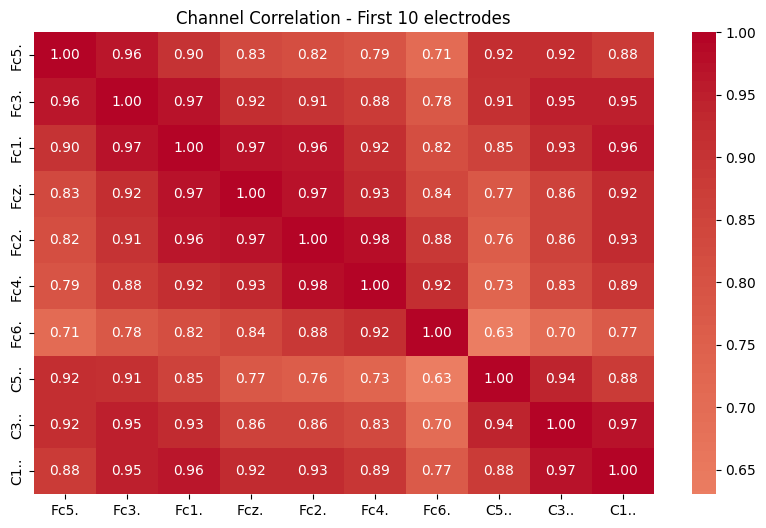

In [38]:
# Channel correlation (which electrodes move together)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# correlation between channels shows spatial relationships
# nearby electrodes on the scalp are expected to correlate highly
# because they pickup overlapping brain regions

sample_data = data[:10, :2000]   # 10 channels, 2000 timepoints
df = pd.DataFrame(sample_data.T, columns = raw.ch_names[:10])

corr = df.corr()

plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, fmt =".2f", cmap = "coolwarm", center = 0)
plt.title("Channel Correlation - First 10 electrodes")
plt.show()

Why EEG channels are naturally highly correlated.

EEG electodes don't measure isolated, independent signals.
They all sit on the SAME head, picking up SHARED electrical activity from a brain that's only a few inches in diameter.


Three real reasons for high correlation:
1. Volume conduction.
brain electrical signals spread through skull and skin before reaching electrodes, reaching multiple points at one. Adjacent (and even distant) electodes pick up overlapping signal.

2. Common reference.
all channels are measured relative to the same reference point. Any noise or drift in that reference shows up identically across ALL channels - artificially inflating corretion.

3.Shared artifcats.
eye blinks, muscle tension, headrtbeat these affect the WHOLE head at once, not just one electrode. this adds correlation that has nothing to do with actual brain activity.

Is this a probelem?

1) It validates our data is real EEG
-high inter channel correlation is expected and actually confirms the data is genuine biological signal, nearby electroded are known to pick up overlapping cortical activity due to volume conduction through the skull.

2) It does affect modeling
Option A : Spatial filtering
 a technique called common average referencing (CAR) subtracts the average of all channels from each channel. This removes shared/common noise and keeps channel -specific signal.


 Option B:
 since our transformer model will learn spatial relationship between channels anyways (seld-attention does this), high- correlation isn't necessarily harmful to model performance.

In [40]:
# Applying CAR (Common Average Reference)
# substract the mean across all channe;s at each timepoint
# removes noise/artifacts shared the whole head

raw_car = raw.copy()
raw_car.set_eeg_reference("average", verbose = False)

print("Applied Common Averaage Reference")


# Compare correlation before/after
data_before = raw.get_data()[:10, :2000]
data_after = raw_car.get_data()[:10, :2000]



corr_before = pd.DataFrame(data_before.T).corr().values.mean()
corr_after = pd.DataFrame(data_after.T).corr().values.mean()


print(f"Average correlation BEFORE CAR: {corr_before:.3f}")
print(f"Average correlation AFTER CAR:  {corr_after:.3f}")

Applied Common Averaage Reference
Average correlation BEFORE CAR: 0.887
Average correlation AFTER CAR:  0.394


In [18]:
# solution for invalid message on Github due to (tqdm.notebook)

import json

path = "/content/drive/MyDrive/Colab Notebooks/01_download_data.ipynb"

with open(path, "r") as f:
    notebook = json.load(f)

# remove the broken widget metadata entirely
if "widgets" in notebook.get("metadata", {}):
    del notebook["metadata"]["widgets"]
    print("✅ Removed broken widget metadata")
else:
    print("No widget metadata found")

with open(path, "w") as f:
    json.dump(notebook, f, indent=1)

print("✅ Notebook fixed and saved")

No widget metadata found
✅ Notebook fixed and saved


In [30]:
# Push to GitHub

import subprocess
import os
import shutil
from datetime import datetime
from google.colab import userdata

GITHUB_TOKEN    = userdata.get("GITHUB_TOKEN")
GITHUB_USERNAME = "the-liyanage"
REPO_NAME       = "neurosynth"

# notebook name
NOTEBOOK_NAME = "01_download_data.ipynb"
# Set git identity
subprocess.run(["git", "config", "--global",
                "user.name", "the-liyanage"])
subprocess.run(["git", "config", "--global",
                "user.email", "hiruniliyanage4@gmail.com"])

# 2. Clone repo fresh (only if not already there)
if not os.path.exists(f"/content/{REPO_NAME}/.git"):
    subprocess.run(["rm", "-rf", f"/content/{REPO_NAME}"])
    os.chdir("/content")
    subprocess.run([
        "git", "clone",
        f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
    ])
    print("✅ Repo cloned fresh")
else:
    print("✅ Repo already exists, skipping clone")

# 3. Copy notebook into repo

src_path = f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}"
dst_path = f"/content/{REPO_NAME}/notebooks/{NOTEBOOK_NAME}"

os.makedirs(f"/content/{REPO_NAME}/notebooks", exist_ok=True)
shutil.copy(src_path, dst_path)

if os.path.exists(dst_path):
  print(f"{NOTEBOOK_NAME} copied.   size:{os.path.getsize(dst_path)} bytes")
else:
  print(f"Copy failed, {dst_path} does not exist!")

# 4. Commit and push
os.chdir(f"/content/{REPO_NAME}")
subprocess.run(["git", "add", "."])

commit_message = "update EDA process further"   # ← change this each time

subprocess.run(["git", "commit", "-m", commit_message])

result = subprocess.run([
    "git", "push",
    f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git",
    "main"
], capture_output=True, text=True)

if result.returncode == 0:
    print(f"✅ Pushed to GitHub! Message: '{commit_message}'")
else:
    print("❌ Push failed:")
    print(result.stderr)

✅ Repo already exists, skipping clone
01_download_data.ipynb copied.   size:16737 bytes
✅ Pushed to GitHub! Message: 'update EDA process further'
